In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import phate
import scprep
import scipy


import sys
import yaml
import phate
import torch
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger
from sklearn.manifold import MDS


sys.path.append("../")
from src.models.lit_encoder import LitAutoencoder
from src.models.lit_encoder import LitDistEncoder
from src.data.make_dataset import train_dataloader
from src.data.make_dataset import make_n_sphere_two
from src.data.make_dataset import make_tree
from src.data.make_dataset import make_live_seq
from src.data.make_dataset import make_pbmc
from src.data.make_dataset import make_ipsc
from src.data.make_dataset import make_swiss
from src.fim_noemb import FIM
import os
from sklearn.decomposition import PCA
import math
import random
import pickle

import h5py
import numpy as np
import scipy.io as sio
import pandas as pd
import sklearn
from sklearn.manifold import Isomap
from sklearn import datasets

#from mpl_tookits import mplot3d


/home/mila/y/yanlei.zhang/.conda/envs/otenv/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
print(pl.__version__)
print(torch.__version__)

2.4.0
2.5.1+cu124


# Define JSD Function

In [3]:


def computeJSD(X):
    
    #NOTE: Input for this function is matrix where the rows are log-transformed probabilites

    jsd = torch.zeros((X.shape[0],X.shape[0]))
    for i in range(X.shape[0]):

        p = X[i,:]
        q = X
        m = (0.5 * (p.exp() + q.exp()))
        

        kone = 0.5 *( (p.exp() * (p - m.log() ) ).sum(dim=1))
        ktwo = 0.5 *( (q.exp() * (q - m.log() ) ).sum(dim=1))
        k = kone + ktwo

        jsd[i,:] = k
     
    jsd.fill_diagonal_(0) #setting diagonal to 0 to avoid nan's
            
    return jsd.to('cuda')
    
def discard_out(metric,n_obs,per):
    
    ns_obs = per*n_obs
    out = int((n_obs - ns_obs)/2)
    sor = np.argsort(metric)
    lwindx = out
    upindx = n_obs - out
    sortind = sor[lwindx:upindx]
    return sortind
    

# Parameter definition

In [19]:
# Data Parameters
dataset = "tree"
n_obs = 1500
n_dim = 10
batch_size = 150

# Model param
encoder_layer = [100,100,2]
decoder_layer = [2,10,10]
emb_dim = 2
activation = "ReLU"
lr = 0.0001
kernel_type = "phate"  # "gaussian" and "phate".
loss_emb = False  # Embedding loss.
loss_dist = True # distance loss in the embedding.
loss_rec = False
bandwitdh = 1  # bandwitdh for the gaussian kernel
t = 20  # time for the gaussian kernel. For PHATE, we use their optimal time.
scale = 0.0005  # scale when we add noise to do the data (before the encoder).
knn = 5 # PHATE kernel number of Nearest Neighbors.
logp=False #Rescale of PHATE parameters

# Trainer param
max_epochs = 150
fast_dev_run = False
accelerator = "gpu"
devices = 1

exp_name = "tree_autoencoder_logp"
seed = torch.randint(0, 1000, size=(1,))

In [14]:
# If you want to save and view in Wandb
wandb = False
logger = WandbLogger(project="tree_autoenocder_logp", name=exp_name) if wandb else False

In [15]:
train_loader = train_dataloader(dataset, n_obs, n_dim, emb_dim, batch_size,knn)


In [16]:
train_loader.dataset.X

tensor([[  3.5376,   0.2250,  -0.7721,  ...,  -1.4629,  -1.6286,  -5.6710],
        [  0.7952,  -9.2358,   3.3618,  ...,   3.6732,   0.0979,   4.6233],
        [ -4.4100,   1.5941,  -4.7739,  ...,  -4.0842,   2.5622,   3.0172],
        ...,
        [-10.7697,  -4.6079,   9.5217,  ...,   2.2403,  -2.6543, -14.5224],
        [ -1.0364,   4.7023,   6.5276,  ...,  -0.9965,  -7.0615,  -5.2524],
        [ -0.3782,   6.8490,  -0.5346,  ...,  -7.0809,  -9.0124,  -7.7292]],
       grad_fn=<ToCopyBackward0>)

# Define pytorch model

In [20]:
# SEED
#pl.utilities.seed.seed_everything(seed=seed)

# data loader for the training set.
# train_loader = train_dataloader(dataset, n_obs, n_dim, emb_dim, batch_size,knn)

# Defining the pytorch lightning model.
model = LitAutoencoder(
    input_dim=n_dim,
    emb_dim=emb_dim,
    encoder_layer=encoder_layer,
    decoder_layer=decoder_layer,
    activation=activation,
    lr=lr,
    kernel_type=kernel_type,
    loss_emb=loss_emb,
    loss_dist=loss_dist,
    loss_rec=loss_rec,
    bandwitdh=bandwitdh,
    t=t,
    scale=scale,
    knn = knn,
    logp=logp
)

# Defining the trainer
# NOTE, we can add more things like gradient clipping, early stopping, Callbacks etc..
# NOTE logger is set to `FALSE`, change to `True` to keep tracks of the metrics.
# NOTE  `enable_checkpointing ` is set to `False`, set to `True` to keep checkpoints of the model.
trainer = Trainer(
    max_epochs=max_epochs,
    fast_dev_run=fast_dev_run,
    accelerator=accelerator,
    devices=devices,
    logger=logger,
    enable_checkpointing=False,
)


# Train the model
trainer.fit(model, train_dataloaders=train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 11.4 K | train
1 | decoder | Sequential | 146    | train
-----------------------------------------------
11.5 K    Trainable params
0         Non-trainable params
11.5 K    Total params
0.046     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.


Instatiating model
[Linear(in_features=10, out_features=100, bias=True), ReLU(), Linear(in_features=100, out_features=100, bias=True), ReLU(), Linear(in_features=100, out_features=2, bias=True), Softmax(dim=1)]
[Linear(in_features=2, out_features=2, bias=True), ReLU(), Linear(in_features=2, out_features=10, bias=True), ReLU(), Linear(in_features=10, out_features=10, bias=True), ReLU()]


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=150` reached.


In [13]:
#save model (and load model)

#torch.save(model.state_dict(),'saved_models/tree_model_5_22.pt')
#model.load_state_dict(torch.load('saved_models/tree_model_1_25_JSD.pt'))



# Randomly sample new data points from tree distribution and encode with NeuralFIM

In [21]:

inference_obs = 1600
tree_data, tree_phate, tree_clusters = make_tree(n_obs=inference_obs, dim=10,emb_dim=2,knn=knn)
model.cuda()
model.eval()
tree_data.cuda()
tree_data = tree_data.to('cuda')
pred = model.encode(tree_data).detach().cpu().numpy()


In [23]:
tree_data.shape

torch.Size([1600, 10])

# Compute FIM, FIM Volume, FIM Trace

In [24]:

#Define model/function
model.cuda()
fcn = model.encode


#FIM
fisher = FIM(tree_data,fcn,inference_obs,n_dim,emb_dim,pred)
fishermat, J = fisher.fit()

#FIM spectra
e,v = fisher.get_eigs()

#FIM volume
volume = fisher.get_volume()

#FIM trace
trace = np.zeros((n_obs))
for i in range(n_obs):
    trace[i] = np.sum(e[i,:])

print("Number of observations:",inference_obs)
print("Ambient dimension:",n_dim)
print("Embedding dimension:",emb_dim)


/home/mila/y/yanlei.zhang/Research/fm_geodesics/notebooks/../src/fim_noemb.py:113: ComplexWarning: Casting complex values to real discards the imaginary part
  FIMeigvec[i,:,:] = eigvec
/home/mila/y/yanlei.zhang/Research/fm_geodesics/notebooks/../src/fim_noemb.py:114: ComplexWarning: Casting complex values to real discards the imaginary part
  FIMeigval[i,:] = eigval


Number of observations: 1600
Ambient dimension: 10
Embedding dimension: 2


# Visualization of PHATE-JSD embedding with FIM metrics

/home/mila/y/yanlei.zhang/.conda/envs/otenv/lib/python3.10/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


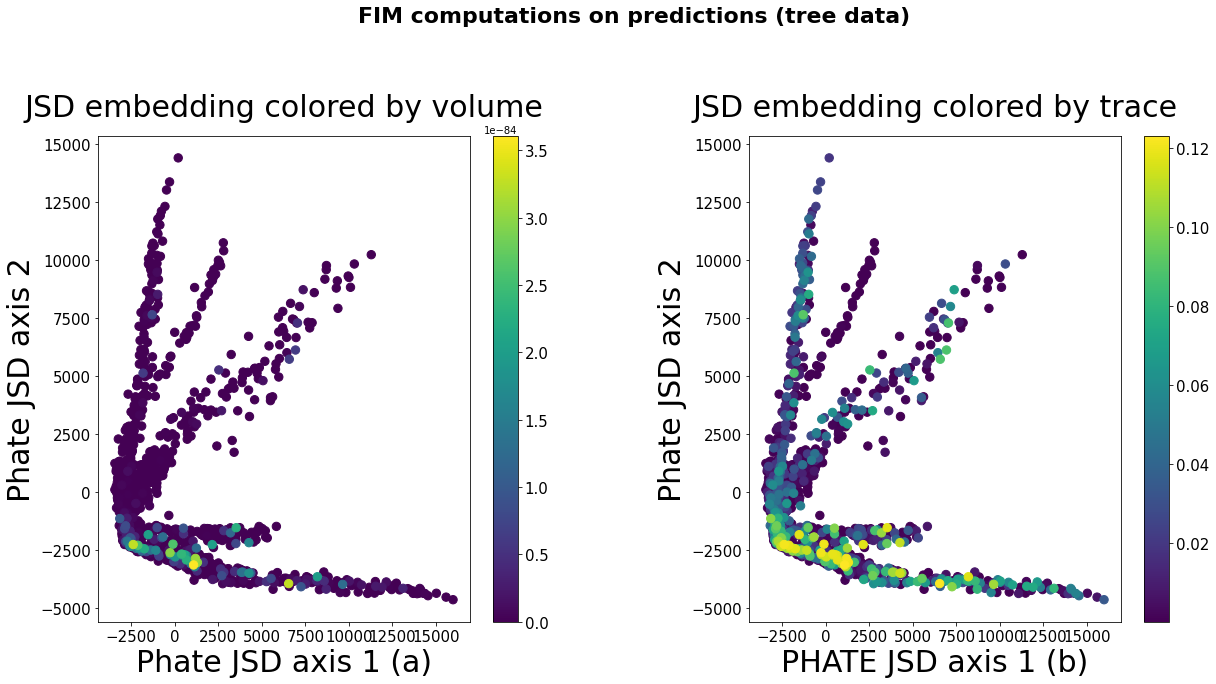

In [25]:

#Pads axis titles
from matplotlib import rcParams
rcParams['axes.titlepad'] = 20 

#Compute middle x% of volume and trace outliers
CI = 0.95 
vind = discard_out(volume,n_obs,CI)
nvolume = volume[vind]

tind = discard_out(trace,n_obs,CI)
ntrace = trace[tind]


#Compute PHATE with JSD-step for visualization
phate_op = phate.PHATE(random_state=42, verbose=False, knn=5).fit(tree_data.cpu().detach().numpy())
diff_pot =torch.tensor(phate_op.diff_potential).float()
gtdist = torch.sqrt( torch.abs(computeJSD(diff_pot)) )
mds_operator = MDS(dissimilarity='precomputed')
phateJSDemb_tree= mds_operator.fit_transform(gtdist.detach().cpu().numpy())


fig = plt.figure(figsize=(20,10))
plt.suptitle("FIM computations on predictions (tree data) ",fontsize=22,fontweight='bold')
plt.subplots_adjust(hspace=1.0,wspace=0.4,top=0.8)



#Volume
plt.subplot(121)
plt.title("JSD embedding colored by volume",fontsize=30)
#plt.scatter(predemb[vind, 0], predemb[vind, 1], c= nvolume)
plt.scatter(phateJSDemb_tree[tind, 0], phateJSDemb_tree[tind, 1], c= nvolume,s=70)
plt.xlabel("Phate JSD axis 1 (a)",fontsize=30)
plt.ylabel("Phate JSD axis 2",fontsize=30)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=15) 



#Trace
plt.subplot(122)
plt.title("JSD embedding colored by trace",fontsize=30)
#plt.scatter(predemb[tind, 0], predemb[tind, 1], c= ntrace)
plt.scatter(phateJSDemb_tree[tind, 0], phateJSDemb_tree[tind, 1], c= ntrace,s=70)
plt.xlabel("PHATE JSD axis 1 (b)",fontsize=30)
plt.ylabel("Phate JSD axis 2",fontsize=30)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=15) 



